<a href="https://colab.research.google.com/github/desalegn816/feedback/blob/main/task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from google.colab import files
uploaded = files.upload()


Saving SE_students.csv to SE_students.csv


In [17]:
# Step 1: Load the dataset
data = pd.read_csv("SE_students.csv")


In [19]:
# Step 2: Verify the dataset
# -----------------------------

# Print column names
print("Columns in dataset:")
print(data.columns)

Columns in dataset:
Index(['Student ID', 'Name', 'Gender', 'Age', 'GPA', 'Major',
       'Interested Domain', 'Projects', 'Future Career', 'Python', 'SQL',
       'Java'],
      dtype='object')


In [21]:
# Print first 20 rows
print("\nFirst 20 rows:")
print(data.head(20))


First 20 rows:
    Student ID                Name  Gender  Age  GPA             Major  \
0            1          John Smith    Male   21  3.5  Computer Science   
1            2       Alice Johnson  Female   20  3.2  Computer Science   
2            3        Robert Davis    Male   22  3.8  Computer Science   
3            4        Emily Wilson  Female   21  3.7  Computer Science   
4            5       Michael Brown    Male   23  3.4  Computer Science   
5            6           Laura Lee  Female   22  3.9  Computer Science   
6            7     William Johnson    Male   20  3.6  Computer Science   
7            8        Sarah Miller  Female   21  3.7  Computer Science   
8            9        James Wilson    Male   23  3.3  Computer Science   
9           10        Olivia Clark  Female   22  3.5  Computer Science   
10          11         Andrew Hall    Male   21  3.8  Computer Science   
11          12         David Jones    Male   22  3.7  Computer Science   
12          13  Elizab

In [23]:
# Print dataset shape (rows and columns)
print("\nDataset shape:")
print(data.shape)


Dataset shape:
(180, 12)


In [25]:
# Check missing values
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
Student ID           0
Name                 0
Gender               0
Age                  0
GPA                  0
Major                0
Interested Domain    0
Projects             0
Future Career        0
Python               0
SQL                  0
Java                 0
dtype: int64


In [27]:
# Remove duplicate rows if they exist
data = data.drop_duplicates()

In [29]:
# Step 3: Data description
# -----------------------------
# Shows statistical summary of dataset
print("\nDataset description:")
print(data.describe())


Dataset description:
       Student ID         Age         GPA
count  180.000000  180.000000  180.000000
mean    90.500000   22.116667    3.615000
std     52.105662    2.823040    0.177341
min      1.000000   20.000000    3.200000
25%     45.750000   21.000000    3.500000
50%     90.500000   22.000000    3.600000
75%    135.250000   22.250000    3.700000
max    180.000000   37.000000    3.900000


In [31]:
# Step 4: Encode label column
# -----------------------------
# This is the target variable
# Change the column name depending on your dataset
label_column = "Java"

# Convert categorical label to numeric
data[label_column] = pd.factorize(data[label_column])[0]

print("\nAfter encoding label:")
print(data.head())


After encoding label:
   Student ID           Name  Gender  Age  GPA             Major  \
0           1     John Smith    Male   21  3.5  Computer Science   
1           2  Alice Johnson  Female   20  3.2  Computer Science   
2           3   Robert Davis    Male   22  3.8  Computer Science   
3           4   Emily Wilson  Female   21  3.7  Computer Science   
4           5  Michael Brown    Male   23  3.4  Computer Science   

         Interested Domain             Projects                 Future Career  \
0  Artificial Intelligence  Chatbot Development   Machine Learning Researcher   
1             Data Science       Data Analytics                Data Scientist   
2     Software Development   E-commerce Website             Software Engineer   
3          Web Development   Full-Stack Web App                 Web Developer   
4            Cybersecurity     Network Security  Information Security Analyst   

    Python     SQL  Java  
0   Strong  Strong     0  
1  Average  Strong     0  


In [33]:
# Step 5: Define Features and Target
# -----------------------------

# Features (all columns except label)
X = data.drop(columns=[label_column])

# Target
y = data[label_column]

In [35]:
# Step 6: Convert categorical features
# -----------------------------
# Convert text columns to numerical values
X = pd.get_dummies(X)

In [37]:
# Step 7: Split dataset
# -----------------------------
# 80% training data
# 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [39]:
# Step 8: Initialize KNN Model
# ----------------------
knn = KNeighborsClassifier(n_neighbors=3)

In [41]:
knn.fit(X_train, y_train)


# -----------------------------
# Step 10: Make predictions
# -----------------------------
y_pred = knn.predict(X_test)


# -----------------------------
# Step 11: Model Evaluation
# -----------------------------

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy * 100, "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 41.66666666666667 %

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.83      0.36         6
           1       0.25      0.10      0.14        10
           2       0.90      0.45      0.60        20

    accuracy                           0.42        36
   macro avg       0.46      0.46      0.37        36
weighted avg       0.61      0.42      0.43        36



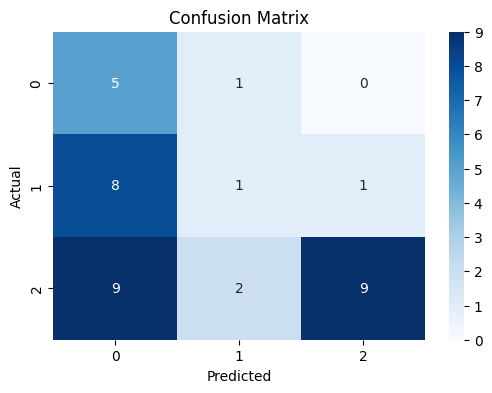

In [43]:
# Step 12: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


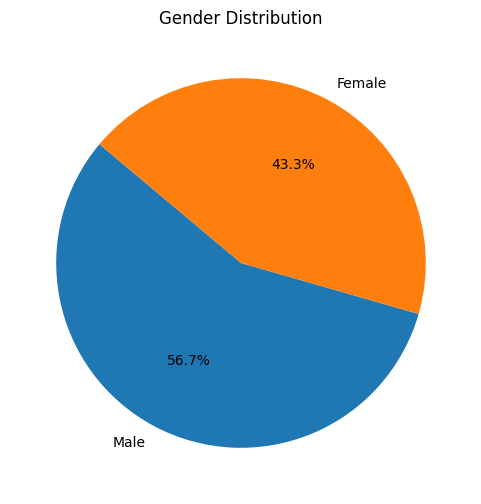

In [52]:
#Step 13: Pie Chart (Gender Distribution Example)
# -----------------------------

# Check if Gender column exists
if "Gender" in data.columns:

    gender_counts = data["Gender"].value_counts()

    plt.figure(figsize=(6,6))

    plt.pie(gender_counts,
            labels=gender_counts.index,
            autopct="%1.1f%%",
            startangle=140)

    plt.title("Gender Distribution")

    plt.show()

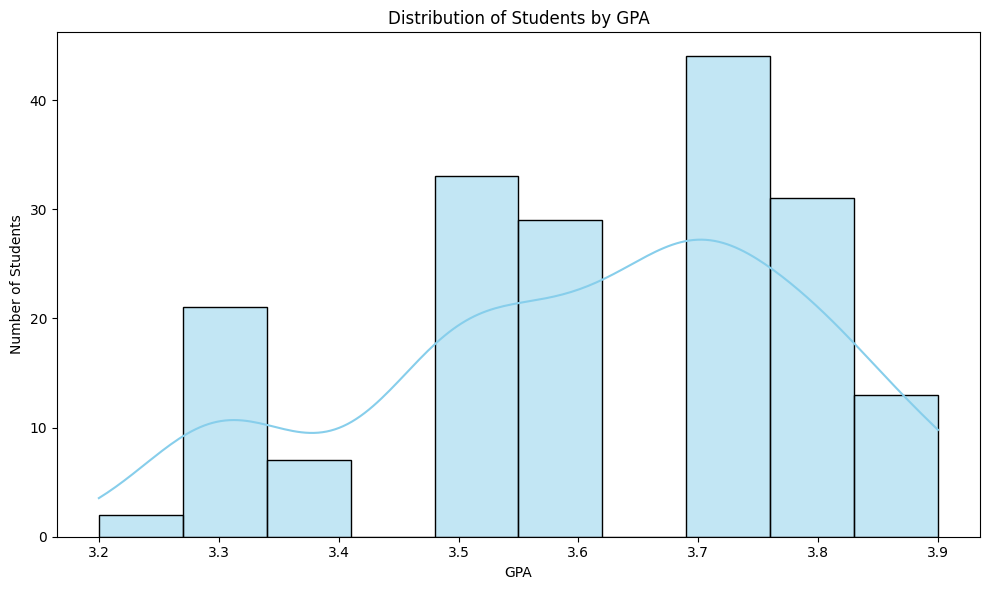

In [53]:
# Step 14: Histogram Chart by GPA
# -----------------------------
# Check if GPA column exists
if "GPA" in data.columns:
    plt.figure(figsize=(10,6))

    # Histogram for GPA distribution
    sns.histplot(data["GPA"], bins=10, kde=True, color="skyblue")

    plt.title("Distribution of Students by GPA")
    plt.xlabel("GPA")
    plt.ylabel("Number of Students")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()